# Function transformation
this is used to tranform not normal data to normal data because most of the ML model work better in NOrmal data 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 


In [2]:
df=pd.read_csv("World-Stock-Prices-Dataset.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Brand_Name,Ticker,Industry_Tag,Country,Dividends,Stock Splits,Capital Gains
0,2025-07-03 00:00:00-04:00,6.630000,6.740000,6.615000,6.640000,4209664.0,peloton,PTON,fitness,usa,0.0,0.0,NaN
1,2025-07-03 00:00:00-04:00,106.750000,108.370003,106.330101,107.339996,560190.0,crocs,CROX,footwear,usa,0.0,0.0,NaN
2,2025-07-03 00:00:00-04:00,122.629997,123.050003,121.550003,121.930000,36600.0,adidas,ADDYY,apparel,germany,0.0,0.0,NaN
3,2025-07-03 00:00:00-04:00,221.705002,224.009995,221.360001,223.410004,29295154.0,amazon,AMZN,e-commerce,usa,0.0,0.0,NaN
4,2025-07-03 00:00:00-04:00,212.145004,214.649994,211.810104,213.550003,34697317.0,apple,AAPL,technology,usa,0.0,0.0,NaN


In [13]:
q1=df["Volume"].quantile(0.25)
q3=df["Volume"].quantile(0.75)
IQR= q3-q1

In [15]:
Min_Range=q1-(1.5*IQR)
Max_Range=q3+(1.5*IQR)
Max_Range, Min_Range

(28252925.0, -14745275.0)

In [19]:
df=df[df["Volume"] <= Max_Range]

C:\Users\Ruhan\AppData\Local\Temp\ipykernel_8448\1194320806.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Volume"])


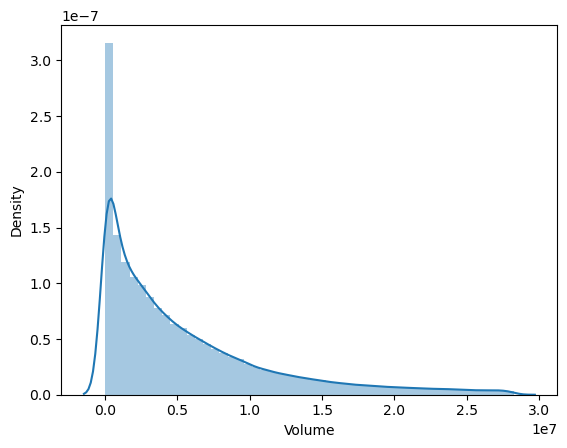

In [20]:
sns.distplot(df["Volume"])
plt.show()

In [21]:
ft=FunctionTransformer(func=np.log1p)
ft.fit(df[["Volume"]])


FunctionTransformer(func=<ufunc 'log1p'>)

In [22]:
df["volumetf"]=ft.transform(df[["Volume"]])
df.head()

C:\Users\Ruhan\AppData\Local\Temp\ipykernel_8448\1698635170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["volumetf"]=ft.transform(df[["Volume"]])


,Date,Open,High,Low,Close,Volume,Brand_Name,Ticker,Industry_Tag,Country,Dividends,Stock Splits,Capital Gains,volumetf
0,2025-07-03 00:00:00-04:00,6.630000,6.740000,6.615000,6.640000,4209664.0,peloton,PTON,fitness,usa,0.0,0.0,NaN,15.252894
1,2025-07-03 00:00:00-04:00,106.750000,108.370003,106.330101,107.339996,560190.0,crocs,CROX,footwear,usa,0.0,0.0,NaN,13.236033
2,2025-07-03 00:00:00-04:00,122.629997,123.050003,121.550003,121.930000,36600.0,adidas,ADDYY,apparel,germany,0.0,0.0,NaN,10.507831
5,2025-07-03 00:00:00-04:00,76.264999,77.029999,75.580002,76.389999,11545304.0,nike,NKE,apparel,usa,0.0,0.0,NaN,16.261789
6,2025-07-03 00:00:00-04:00,105.949997,105.969902,104.055000,104.059998,3535290.0,target,TGT,retail,usa,0.0,0.0,NaN,15.078306


C:\Users\Ruhan\AppData\Local\Temp\ipykernel_8448\422784106.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["volumetf"])


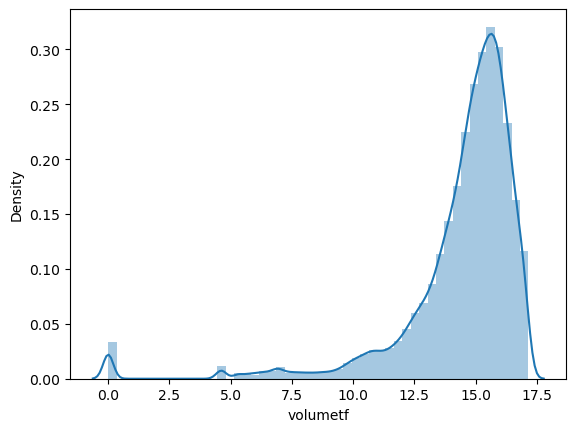

In [23]:
sns.distplot(df["volumetf"])
plt.show()

# Train Test Data Split

In [2]:
df=pd.read_csv("Boston_like_509_rows.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,House_Price
0,1.40780,95.0,4.44,0,0.763,5.398,63.6,11.3392,10,335,17.1,223.08,27.68,42.2
1,9.03036,40.0,6.12,0,0.784,4.458,49.2,6.5440,18,687,20.6,21.84,10.51,30.3
2,3.95024,80.0,20.14,0,0.623,6.974,37.4,11.4412,22,592,20.7,388.74,27.62,39.3
3,2.73883,0.0,14.08,0,0.569,7.955,95.0,10.1612,11,707,12.1,205.05,2.04,37.1
4,0.50887,12.5,21.25,0,0.601,6.509,64.0,4.9867,16,534,19.8,116.35,14.89,14.3


In [6]:
input_Data=df.iloc[:, :-1]
output_Data=df["House_Price"]


In [9]:
from sklearn.model_selection import train_test_split

In [17]:
x_Train,x_Test,y_Train,y_Test=train_test_split(input_Data,output_Data,test_size=0.25)

In [13]:
x_Train.shape

(381, 13)

In [19]:
x_Test.shape

(128, 13)

# REGRESSION ANALYSIS

we use regression analysis when we have supervised learning and output is continuous 

# 1) Simple Linear Regression

when we have single independent variable or single input 
formula for linear is y = mx + c

In [20]:
dataset=pd.read_csv("placement.csv")
dataset.head()

,cgpa,package
0,5.35,2.18
1,6.68,2.43
2,5.67,2.25
3,5.00,2.45
4,5.75,2.50


In [21]:
dataset.isnull().sum()

cgpa       0
package    0
dtype: int64

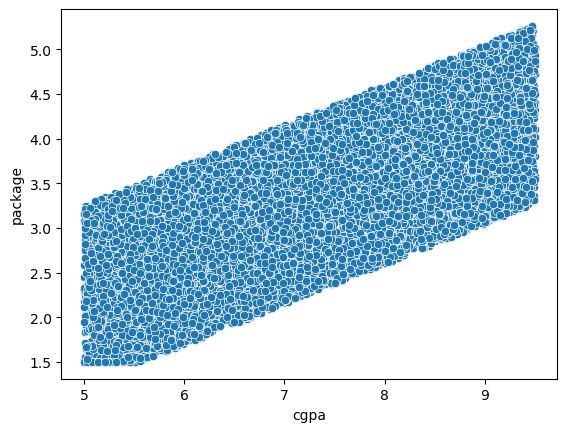

In [24]:
sns.scatterplot(x="cgpa",y="package",data=dataset)
plt.show()

In [26]:
x=dataset[["cgpa"]]
y=dataset["package"]

In [46]:
x_Train,x_Test,y_Train,y_Test=train_test_split(x,y,test_size=0.25,random_state=75)

In [30]:
x_Train.shape

(7500, 1)

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
Lr=LinearRegression()

In [47]:
Lr.fit(x_Train,y_Train)

LinearRegression()

In [48]:
Lr.predict([[5.75]])

C:\ProgramData\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.59089674])

In [49]:
Lr.score(x_Test,y_Test)

0.4957884530571489

In [50]:
Lr.coef_

array([0.45104644])

In [51]:
Lr.intercept_

-0.002620316828715108

In [61]:
pred_Value=Lr.coef_*5.75 + Lr.intercept_
pred_Value

array([2.59089674])

In [52]:
y_pred=Lr.predict(x)

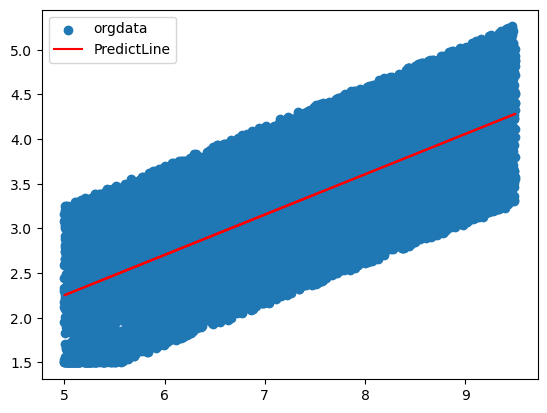

In [59]:
plt.scatter(x, y, label="orgdata")
plt.plot(x, y_pred, label="PredictLine",c="red")

plt.legend()
plt.show()